In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

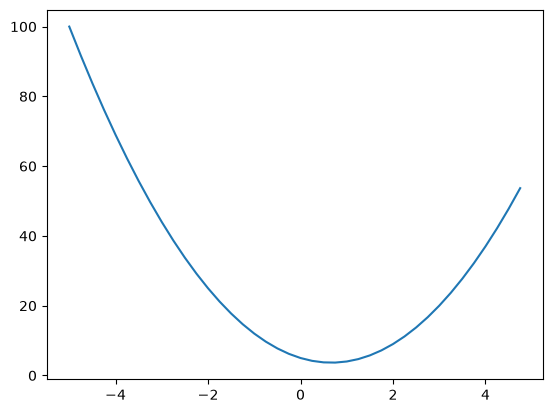

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.0000001
x = -3.0
(f(x + h) - f(x))/h

-21.999999688659955

In [6]:
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1: ', d1)
print('d2: ', d2)
print('slope', (d2-d1)/h)

d1:  4.0
d2:  4.000000099999999
slope 0.999999993922529


In [7]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0.0
        self._backward = lambda: None
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)

        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [8]:
a = Value(2.0)
b = Value(3.0)
a / b

Value(data=0.6666666666666666)

In [9]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        # create square node to each variable
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [10]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label ='x1w1'
x2w2 = x2 * w2; x2w2.label ='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'

n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'


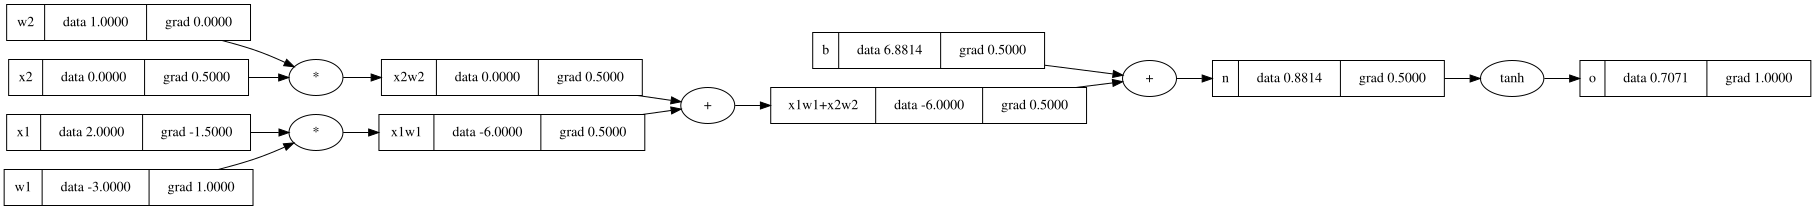

In [11]:
o.backward()
draw_dot(o)

In [12]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label ='x1w1'
x2w2 = x2 * w2; x2w2.label ='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'

n = x1w1x2w2 + b; n.label='n'
# ----
e = (2*n).exp(); e.label='e'
o = (e - 1)/(e + 1); o.label='o'

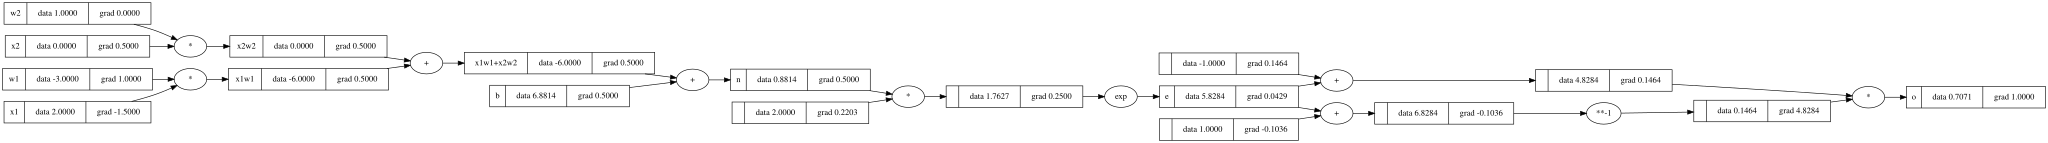

In [13]:
o.backward()
draw_dot(o)

In [14]:
import torch

In [15]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad=True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad=True
b  = torch.Tensor([6.8813735870195432]).double(); b.requires_grad=True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

0.7071066904050358


In [16]:
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [40]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        p = self.w + [self.b] 
        return p

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nout): # nin as starting point, nout as list of layer's length
        sz = [nin] + nout
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nout))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [53]:
n = MLP(3, [1])

In [54]:
n.parameters()

[Value(data=-0.5170355397867372),
 Value(data=-0.15383410083507432),
 Value(data=-0.9951338072097082),
 Value(data=0.32620524419778585)]

In [55]:
xs = [
    [2.0, 3.0, -1.0], # 1.0
    [3.0, -1.0, 0.5], # -1.0
    [0.5, 1.0, 1.0],  # -1.0
    [1.0, 1.0, -1.0], # 1.0
]
ys = [1.0, -1.0, -1.0, 1.0]

In [56]:
epoch = 1000
lr = 0.01

for k in range(epoch):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -lr * p.grad

    if k % 100 == 0:
        print(k, loss.data) 


0 1.6074259524848369
100 0.05536254769066684
200 0.030264486411820148
300 0.020714051270645337
400 0.01571597747912253
500 0.012650440087563908
600 0.010581102963348677
700 0.009091432383212491
800 0.007968338501512495
900 0.0070916171415857454


In [57]:
ypred

[Value(data=0.9708685294232253),
 Value(data=-0.9772934338687568),
 Value(data=-0.940522642088078),
 Value(data=0.9613616610420349)]

In [58]:
n.parameters()

[Value(data=-0.3774144795184156),
 Value(data=0.2605624107336768),
 Value(data=-1.9476585691014874),
 Value(data=0.13297960411331494)]